In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
destinations_df = pd.read_csv("2000_Destinations_with_Popularity_and_BestTime.csv")
reviews_df = pd.read_csv("FINAL_2000_Reviews_ENRICHED.csv")
userhistory_df = pd.read_csv("FINAL_2000_UserHistory_CLEANED.csv")
users_df = pd.read_csv("FINAL_2000_Users_ENRICHED.csv")

In [6]:
destinations_df.head()

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,1,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar
1,2,Red Fort,Delhi,Historical,9.3525,Oct-Mar
2,3,Golden Temple,Punjab,Religious,8.6940,Oct-Mar
3,4,Amer Fort,Rajasthan,Historical,8.2926,Oct-Mar
4,5,Hawa Mahal,Rajasthan,Historical,6.9600,Oct-Mar


In [7]:
destinations_df.shape

(2000, 6)

In [8]:
destinations_df = destinations_df.rename(columns={'destinationId': 'DestinationID'})
destinations_df = destinations_df.rename(columns={'destinationName': 'Name'})
destinations_df = destinations_df.rename(columns={'state': 'State'})
destinations_df = destinations_df.rename(columns={'category': 'Type'})

In [9]:
destinations_df.head()

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,1,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar
1,2,Red Fort,Delhi,Historical,9.3525,Oct-Mar
2,3,Golden Temple,Punjab,Religious,8.6940,Oct-Mar
3,4,Amer Fort,Rajasthan,Historical,8.2926,Oct-Mar
4,5,Hawa Mahal,Rajasthan,Historical,6.9600,Oct-Mar


In [10]:
destinations_df['Name'].value_counts()

Name
Krishnagiri Fort          2
Venkataramana Temple      2
Athirappilly Falls        2
Ungma Village             2
Krishna's Butter Ball     2
                         ..
Naneghat Ancient Pass     1
Lenyadri Caves            1
Ozar Vighnahar Ganpati    1
Malshej Falls             1
Taj Mahal                 1
Name: count, Length: 1985, dtype: int64

In [11]:
reviews_df.head()

,ReviewID,DestinationID,UserID,Rating,ReviewText
0,1,1,1943,5,A historical wonder with rich heritage and arc...
1,2,1,543,2,A historical wonder with rich heritage and arc...
2,3,1,1571,5,A historical wonder with rich heritage and arc...
3,4,2,854,5,A historical wonder with rich heritage and arc...
4,5,2,1309,1,A historical wonder with rich heritage and arc...


In [12]:
reviews_df = reviews_df.rename(columns={'reviewId': 'ReviewID'})
reviews_df = reviews_df.rename(columns={'destinationId': 'DestinationID'})
reviews_df = reviews_df.rename(columns={'userId': 'UserID'})
reviews_df = reviews_df.rename(columns={'rating': 'Rating'})
reviews_df = reviews_df.rename(columns={'reviewText': 'ReviewText'})

In [13]:
reviews_df.head()

,ReviewID,DestinationID,UserID,Rating,ReviewText
0,1,1,1943,5,A historical wonder with rich heritage and arc...
1,2,1,543,2,A historical wonder with rich heritage and arc...
2,3,1,1571,5,A historical wonder with rich heritage and arc...
3,4,2,854,5,A historical wonder with rich heritage and arc...
4,5,2,1309,1,A historical wonder with rich heritage and arc...


In [14]:
reviews_df.shape

(6000, 5)

In [15]:
userhistory_df.head()

,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating
0,1,2000,1,21/2/2024,4
1,2,660,1,15/1/2024,4
2,3,463,1,12/3/2024,5
3,4,541,2,1/3/2024,4
4,5,1457,2,21/1/2024,5


In [16]:
userhistory_df.shape

(6000, 5)

In [17]:
users_df.head()

,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,Suresh1,suresh1@gmail.com,Nature,Male,2,1
1,2,Anita2,anita2@gmail.com,Adventure,Female,2,0
2,3,Prakash3,prakash3@gmail.com,City,Male,1,0
3,4,Manoj4,manoj4@gmail.com,Adventure,Male,2,1
4,5,Manoj5,manoj5@gmail.com,Adventure,Male,2,0


In [18]:
users_df = users_df.rename(columns={'userId': 'UserID'})
users_df = users_df.rename(columns={'userName': 'Name'})
users_df = users_df.rename(columns={'email': 'Email'})
users_df = users_df.rename(columns={'preferences': 'Preferences'})
users_df = users_df.rename(columns={'gender': 'Gender'})
users_df = users_df.rename(columns={'numberOfAdults': 'NumberofAdults'})
users_df = users_df.rename(columns={'numberOfChildren': 'NumberofChildren'})

In [19]:
users_df.head()

,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,Suresh1,suresh1@gmail.com,Nature,Male,2,1
1,2,Anita2,anita2@gmail.com,Adventure,Female,2,0
2,3,Prakash3,prakash3@gmail.com,City,Male,1,0
3,4,Manoj4,manoj4@gmail.com,Adventure,Male,2,1
4,5,Manoj5,manoj5@gmail.com,Adventure,Male,2,0


In [20]:
# Merge datasets step-by-step
# Step 1: Merge reviews with destinations on 'DestinationID'
reviews_destinations = pd.merge(reviews_df, destinations_df, on='DestinationID', how='inner')

# Step 2: Merge the result with user history on 'UserID'
reviews_destinations_userhistory = pd.merge(reviews_destinations, userhistory_df, on='UserID', how='inner')

# Step 3: Merge the result with users on 'UserID'
df = pd.merge(reviews_destinations_userhistory, users_df, on='UserID', how='inner')

df

,ReviewID,DestinationID_x,UserID,Rating,ReviewText,Name_x,State,Type,Popularity,BestTimeToVisit,HistoryID,DestinationID_y,VisitDate,ExperienceRating,Name_y,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,1,1943,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,3726,1242,6/2/2024,4,Aarti1943,aarti1943@gmail.com,Adventure,Female,1,1
1,2,1,543,2,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,3480,1160,11/1/2024,5,Vivek543,vivek543@gmail.com,Beach,Male,3,0
2,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,785,262,20/2/2024,5,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
3,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,925,309,31/1/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
4,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,1045,349,20/2/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18007,5999,2000,493,5,A wonderful and memorable travel experience! V...,Gangapur Dam,Maharashtra,Engineering,7.3398,Oct-Mar,3075,1025,7/3/2024,3,Kunal493,kunal493@gmail.com,Nature,Male,3,0
18008,5999,2000,493,5,A wonderful and memorable travel experience! V...,Gangapur Dam,Maharashtra,Engineering,7.3398,Oct-Mar,3869,1290,4/1/2024,3,Kunal493,kunal493@gmail.com,Nature,Male,3,0
18009,5999,2000,493,5,A wonderful and memorable travel experience! V...,Gangapur Dam,Maharashtra,Engineering,7.3398,Oct-Mar,5585,1862,10/2/2024,3,Kunal493,kunal493@gmail.com,Nature,Male,3,0
18010,6000,2000,979,4,A wonderful and memorable travel experience! V...,Gangapur Dam,Maharashtra,Engineering,7.3398,Oct-Mar,1758,586,25/1/2024,4,Aarti979,aarti979@gmail.com,City,Female,2,1


In [21]:
df.shape

(18012, 20)

In [22]:
df.drop_duplicates(inplace=True)
df.shape

(18012, 20)

In [23]:
df.to_csv("final_trs_df.csv",index=True)
df.shape

(18012, 20)

In [24]:
df.head()

,ReviewID,DestinationID_x,UserID,Rating,ReviewText,Name_x,State,Type,Popularity,BestTimeToVisit,HistoryID,DestinationID_y,VisitDate,ExperienceRating,Name_y,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,1,1943,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,3726,1242,6/2/2024,4,Aarti1943,aarti1943@gmail.com,Adventure,Female,1,1
1,2,1,543,2,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,3480,1160,11/1/2024,5,Vivek543,vivek543@gmail.com,Beach,Male,3,0
2,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,785,262,20/2/2024,5,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
3,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,925,309,31/1/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
4,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,1045,349,20/2/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1


In [25]:
destinations_df['Type'].value_counts()

Type
Nature          476
Historical      466
Religious       431
Wildlife        114
Adventure       104
Culture          94
Beach            87
Leisure          69
Education        60
Engineering      44
Shopping         22
Cuisine          12
Science          11
Hill Station      8
Food              1
Sports            1
Name: count, dtype: int64

In [26]:
df.shape

(18012, 20)

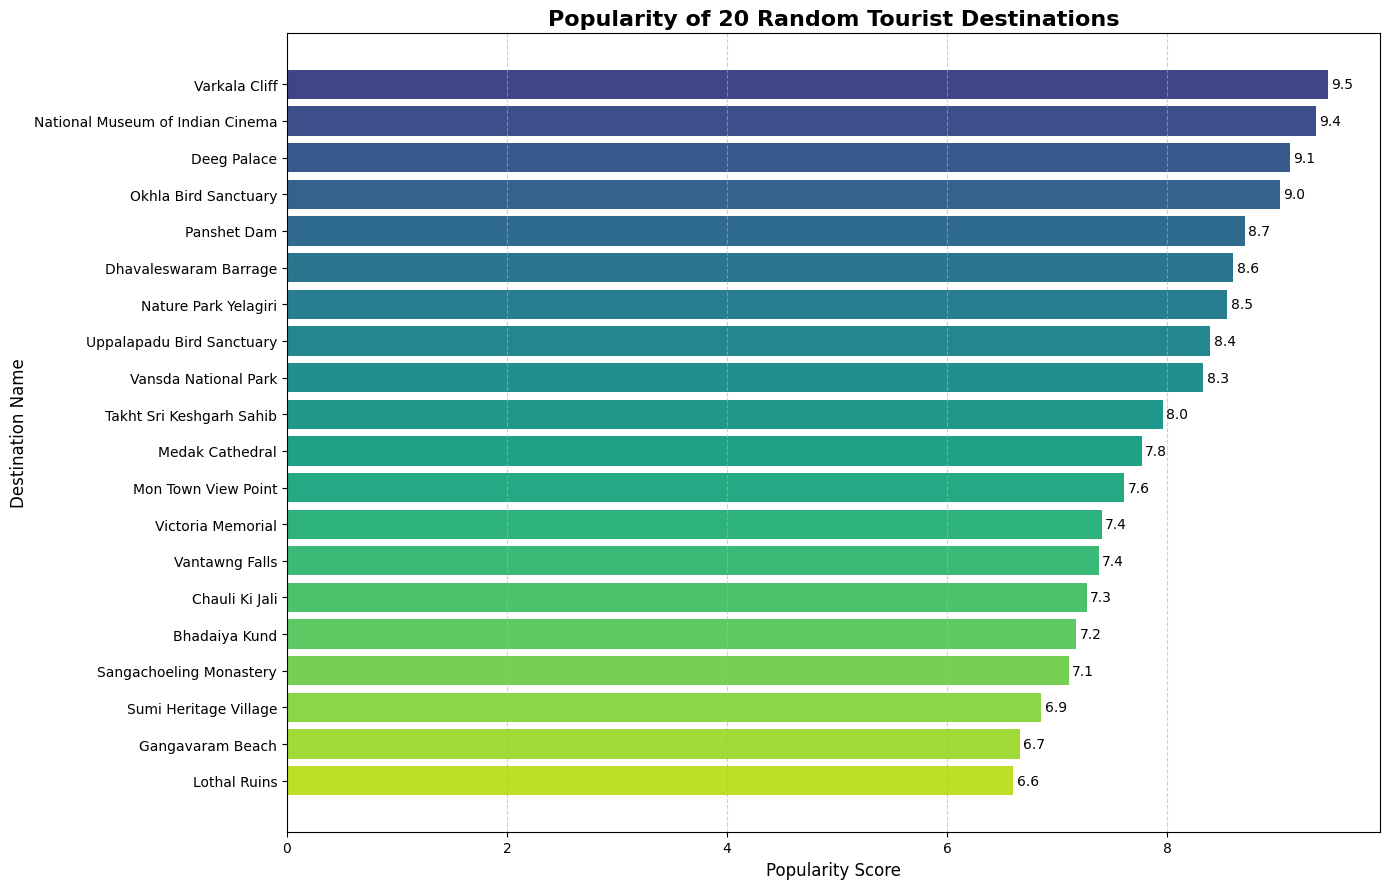

In [27]:
# # 1. Destination Popularity
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Popularity', y='Name', data=destinations_df.sort_values(by='Popularity', ascending=False), palette='viridis')
# plt.title('Most Popular Destinations')
# plt.xlabel('Popularity Score')
# plt.ylabel('Destination')
# plt.show()

# destination popularity plot   second plot 
# 1. Destination Popularit
# Random 20 destinations
random_20_destinations = destinations_df.sample(n=20, random_state=10)

# Sort by popularity
random_20_destinations = random_20_destinations.sort_values(
    by='Popularity', ascending=False
)

# Color gradient based on popularity
colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(random_20_destinations))
)

# Plot
plt.figure(figsize=(14, 9))
bars = plt.barh(
    random_20_destinations['Name'],
    random_20_destinations['Popularity'],
    color=colors
)
plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va='center',
        fontsize=10
    )

plt.title(
    "Popularity of 20 Random Tourist Destinations",
    fontsize=16,
    fontweight='bold'
)
plt.xlabel("Popularity Score", fontsize=12)
plt.ylabel("Destination Name", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2112\1416000048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Type', data=destinations_df, order=destinations_df['Type'].value_counts().index, palette='coolwarm')


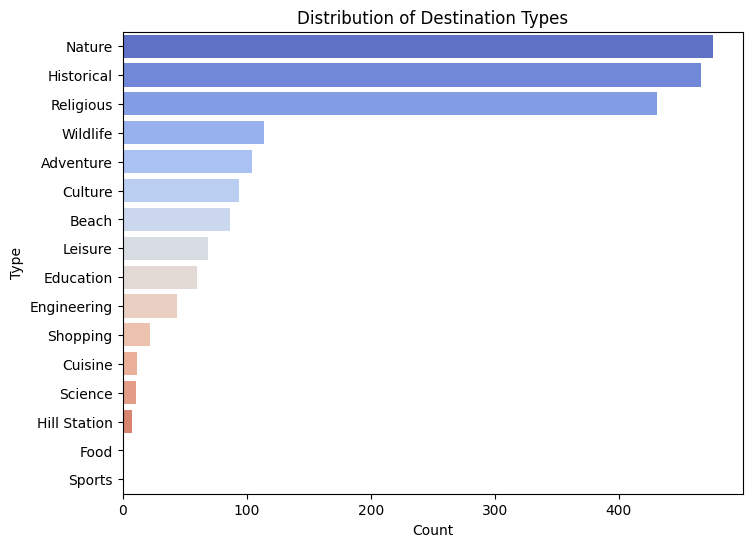

In [28]:

# 2. Destination Types Distribution
plt.figure(figsize=(8, 6))
sns.countplot(y='Type', data=destinations_df, order=destinations_df['Type'].value_counts().index, palette='coolwarm')
plt.title('Distribution of Destination Types')
plt.xlabel('Count')
plt.ylabel('Type')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2112\3398856787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='BestTimeToVisit', data=destinations_df, order=destinations_df['BestTimeToVisit'].value_counts().index, palette='mako')


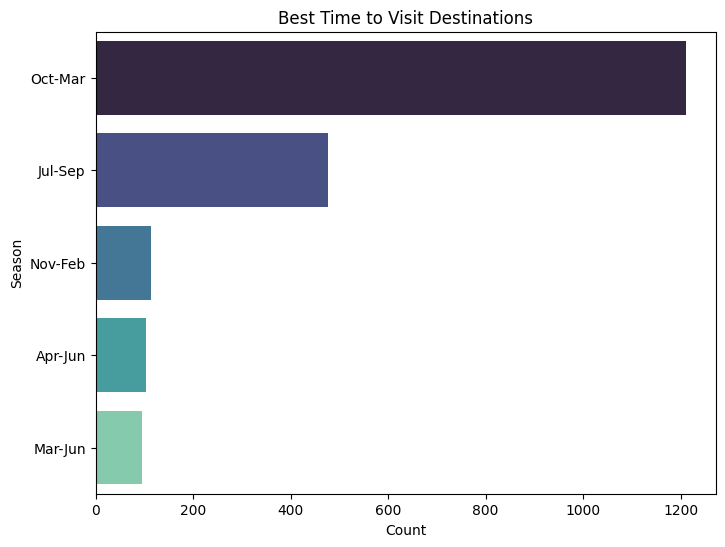

In [29]:
# 3. Best Time to Visit Distribution
plt.figure(figsize=(8, 6))
sns.countplot(y='BestTimeToVisit', data=destinations_df, order=destinations_df['BestTimeToVisit'].value_counts().index, palette='mako')
plt.title('Best Time to Visit Destinations')
plt.xlabel('Count')
plt.ylabel('Season')
plt.show()

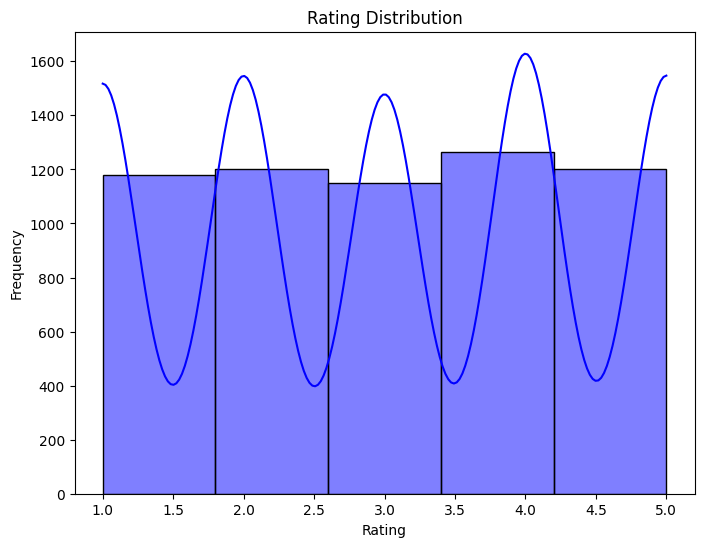

In [30]:
# 4. Ratings Distribution
plt.figure(figsize=(8, 6))
sns.histplot(reviews_df['Rating'], bins=5, kde=True, color='blue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [31]:
df.head()

,ReviewID,DestinationID_x,UserID,Rating,ReviewText,Name_x,State,Type,Popularity,BestTimeToVisit,HistoryID,DestinationID_y,VisitDate,ExperienceRating,Name_y,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,1,1943,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,3726,1242,6/2/2024,4,Aarti1943,aarti1943@gmail.com,Adventure,Female,1,1
1,2,1,543,2,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,3480,1160,11/1/2024,5,Vivek543,vivek543@gmail.com,Beach,Male,3,0
2,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,785,262,20/2/2024,5,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
3,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,925,309,31/1/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
4,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,1045,349,20/2/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1


In [32]:
df['features']=df['Type'] + " " +df['State'] + " " +df['BestTimeToVisit'] + " " + df['Preferences']

In [33]:
df.head()

,ReviewID,DestinationID_x,UserID,Rating,ReviewText,Name_x,State,Type,Popularity,BestTimeToVisit,...,DestinationID_y,VisitDate,ExperienceRating,Name_y,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren,features
0,1,1,1943,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,...,1242,6/2/2024,4,Aarti1943,aarti1943@gmail.com,Adventure,Female,1,1,Historical Uttar Pradesh Oct-Mar Adventure
1,2,1,543,2,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,...,1160,11/1/2024,5,Vivek543,vivek543@gmail.com,Beach,Male,3,0,Historical Uttar Pradesh Oct-Mar Beach
2,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,...,262,20/2/2024,5,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1,Historical Uttar Pradesh Oct-Mar Nature
3,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,...,309,31/1/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1,Historical Uttar Pradesh Oct-Mar Nature
4,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,Oct-Mar,...,349,20/2/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1,Historical Uttar Pradesh Oct-Mar Nature


In [34]:
df.shape

(18012, 21)

In [35]:
vectorizer = TfidfVectorizer(stop_words='english')
destination_features = vectorizer.fit_transform(df['features'])

In [36]:
destination_features.toarray()

array([[0.36975644, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(18012, 68))

In [37]:
df['features']

0        Historical Uttar Pradesh Oct-Mar Adventure
1            Historical Uttar Pradesh Oct-Mar Beach
2           Historical Uttar Pradesh Oct-Mar Nature
3           Historical Uttar Pradesh Oct-Mar Nature
4           Historical Uttar Pradesh Oct-Mar Nature
                            ...                    
18007        Engineering Maharashtra Oct-Mar Nature
18008        Engineering Maharashtra Oct-Mar Nature
18009        Engineering Maharashtra Oct-Mar Nature
18010          Engineering Maharashtra Oct-Mar City
18011          Engineering Maharashtra Oct-Mar City
Name: features, Length: 18012, dtype: object

In [38]:
df.shape

(18012, 21)

In [39]:
cosine_sim=cosine_similarity(destination_features,destination_features)
cosine_sim

array([[1.        , 0.85792866, 0.88272209, ..., 0.10651178, 0.1023136 ,
        0.1023136 ],
       [0.85792866, 1.        , 0.87725006, ..., 0.10585151, 0.10167935,
        0.10167935],
       [0.88272209, 0.87725006, 1.        , ..., 0.20451133, 0.1046178 ,
        0.1046178 ],
       ...,
       [0.10651178, 0.10585151, 0.20451133, ..., 1.        , 0.87044681,
        0.87044681],
       [0.1023136 , 0.10167935, 0.1046178 , ..., 0.87044681, 1.        ,
        1.        ],
       [0.1023136 , 0.10167935, 0.1046178 , ..., 0.87044681, 1.        ,
        1.        ]], shape=(18012, 18012))

In [40]:
def recommend_destinations(user_id, userhistory_df, destinations_df, cosine_sim):

    OUTPUT_COLUMNS = [
        'DestinationID', 'Name', 'State', 'Type',
        'Popularity', 'BestTimeToVisit'
    ]

    # Reset index to align with cosine_sim
    destinations_df = destinations_df.reset_index(drop=True)
    max_valid_index = len(destinations_df) - 1

    # Get visited destination IDs for the user
    visited_ids = userhistory_df[
        userhistory_df['UserID'] == user_id
    ]['DestinationID']

    # Convert DestinationID → row indices
    visited_indices = destinations_df[
        destinations_df['DestinationID'].isin(visited_ids)
    ].index.values

    # -------------------------------
    # Cold-start user
    # -------------------------------
    if len(visited_indices) == 0:
        return destinations_df.sample(5)[OUTPUT_COLUMNS].reset_index(drop=True)

    # -------------------------------
    # Safety: trim cosine_sim
    # -------------------------------
    cosine_sim = cosine_sim[:len(destinations_df), :len(destinations_df)]

    # Compute similarity scores
    similar_scores = cosine_sim[visited_indices].sum(axis=0)

    # Rank destinations
    ranked_indices = np.argsort(similar_scores)[::-1]

    recommendations = []

    for idx in ranked_indices:

        # Hard safety check
        if idx > max_valid_index:
            continue

        if idx not in visited_indices:
            recommendations.append(
                destinations_df.iloc[idx][OUTPUT_COLUMNS].to_dict()
            )

        if len(recommendations) == 5:
            break

    # -------------------------------
    # Fallback if nothing found
    # -------------------------------
    if len(recommendations) == 0:
        return destinations_df.sample(5)[OUTPUT_COLUMNS].reset_index(drop=True)

    # Return final DataFrame
    return pd.DataFrame(recommendations, columns=OUTPUT_COLUMNS)


# ===============================
# OUTPUT / DISPLAY CODE
# ===============================

# Call the function
df = recommend_destinations(
    user_id=1,
    userhistory_df=userhistory_df,
    destinations_df=destinations_df,
    cosine_sim=cosine_sim
)

# Display output (Jupyter Notebook)
df


,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,1700,Parambikulam Tiger Reserve,Kerala,Wildlife,8.1447,Nov-Feb
1,1701,Vizag Fishing Harbour,Andhra Pradesh,Cuisine,9.3980,Oct-Mar
2,1703,Submarine Museum (Kursura),Andhra Pradesh,Education,7.4290,Oct-Mar
3,1704,TU 142 Aircraft Museum,Andhra Pradesh,Education,8.0141,Oct-Mar
4,1577,Islamnagar Fort,Madhya Pradesh,Historical,6.5615,Oct-Mar


### collaborative filtering

In [41]:
df.shape

(5, 6)

In [42]:
# Create user-item matrix
user_item_matrix = userhistory_df.pivot_table(
    index='UserID',
    columns='DestinationID',
    values='ExperienceRating'
)
user_item_matrix.fillna(0, inplace=True)

# Compute similarity
user_similarity = cosine_similarity(user_item_matrix)

In [43]:
# Function to recommend destinations based on user similarity
def collaborative_recommend(user_id, user_similarity, user_item_matrix, destinations_df):
    """
    Recommends destinations based on collaborative filtering.

    Args:
    - user_id: ID of the user for whom recommendations are to be made.
    - user_similarity: Cosine similarity matrix for users.
    - user_item_matrix: User-item interaction matrix (e.g., ratings or preferences).
    - destinations_df: DataFrame containing destination details.

    Returns:
    - DataFrame with recommended destinations and their details.
    """
    # Find similar users
    similar_users = user_similarity[user_id - 1]
    
    # Get the top 5 most similar users
    similar_users_idx = np.argsort(similar_users)[::-1][1:6]
    
    # Get the destinations liked by similar users
    similar_user_ratings = user_item_matrix.iloc[similar_users_idx].mean(axis=0)
    
    # Recommend the top 5 destinations
    recommended_destinations_ids = similar_user_ratings.sort_values(ascending=False).head(5).index
    
    # Filter the destinations DataFrame to include detailed information
    recommendations = destinations_df[destinations_df['DestinationID'].isin(recommended_destinations_ids)][[
        'DestinationID', 'Name', 'State', 'Type', 'Popularity', 'BestTimeToVisit'
    ]]
    
    return recommendations

# Example: Collaborative recommendations for user 1
collaborative_recommendations = collaborative_recommend(1, user_similarity, user_item_matrix, destinations_df)

# Display recommendations
collaborative_recommendations

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
79,80,Vaikuntaperumal Temple,Tamil Nadu,Religious,6.8391,Oct-Mar
503,504,Bhimbetka Rock Shelters,Madhya Pradesh,Historical,8.9403,Oct-Mar
614,615,Assam State Museum,Assam,Education,9.1203,Oct-Mar
1025,1026,Jang-e-Azadi Memorial,Punjab,Culture,7.9180,Oct-Mar
1402,1403,Khadevasla Dam,Maharashtra,Nature,6.6007,Jul-Sep


In [44]:
# Example: Collaborative recommendations for user 1
collaborative_recommendations = collaborative_recommend(11, user_similarity, user_item_matrix, destinations_df)

# Display recommendations
collaborative_recommendations

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
53,54,Dudhsagar Falls,Goa,Nature,9.1842,Jul-Sep
84,85,Daria Daulat Bagh,Karnataka,Historical,7.4265,Oct-Mar
377,378,Auroville Matrimandir,Puducherry,Religious,6.5604,Oct-Mar
620,621,Mokokchung Village,Nagaland,Culture,7.0458,Oct-Mar
968,969,Khardung La Pass,Ladakh,Adventure,8.1955,Apr-Jun


In [45]:
# Example: Collaborative recommendations for user 1
collaborative_recommendations = collaborative_recommend(100, user_similarity, user_item_matrix, destinations_df)

# Display recommendations
collaborative_recommendations

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
154,155,Nagoa Beach,Daman & Diu,Beach,9.4577,Mar-Jun
308,309,Kuruva Island,Kerala,Nature,8.8843,Jul-Sep
920,921,Bihar Museum,Bihar,Culture,9.1049,Oct-Mar
1107,1108,Garwaji Waterfall,Rajasthan,Nature,8.7730,Jul-Sep
1121,1122,Bapu Bazaar,Rajasthan,Shopping,9.3673,Oct-Mar


In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # Using regressor for continuous target
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load and preprocess the data
data = pd.read_csv('final_trs_df.csv')
data.head()

,Unnamed: 0,ReviewID,DestinationID_x,UserID,Rating,ReviewText,Name_x,State,Type,Popularity,...,HistoryID,DestinationID_y,VisitDate,ExperienceRating,Name_y,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,0,1,1,1943,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,...,3726,1242,6/2/2024,4,Aarti1943,aarti1943@gmail.com,Adventure,Female,1,1
1,1,2,1,543,2,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,...,3480,1160,11/1/2024,5,Vivek543,vivek543@gmail.com,Beach,Male,3,0
2,2,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,...,785,262,20/2/2024,5,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
3,3,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,...,925,309,31/1/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1
4,4,3,1,1571,5,A historical wonder with rich heritage and arc...,Taj Mahal,Uttar Pradesh,Historical,7.6179,...,1045,349,20/2/2024,3,Pooja1571,pooja1571@gmail.com,Nature,Female,3,1


In [47]:
data.dtypes

Unnamed: 0            int64
ReviewID              int64
DestinationID_x       int64
UserID                int64
Rating                int64
ReviewText           object
Name_x               object
State                object
Type                 object
Popularity          float64
BestTimeToVisit      object
HistoryID             int64
DestinationID_y       int64
VisitDate            object
ExperienceRating      int64
Name_y               object
Email                object
Preferences          object
Gender               object
NumberOfAdults        int64
NumberOfChildren      int64
dtype: object

In [48]:
print(data.columns.tolist())


['Unnamed: 0', 'ReviewID', 'DestinationID_x', 'UserID', 'Rating', 'ReviewText', 'Name_x', 'State', 'Type', 'Popularity', 'BestTimeToVisit', 'HistoryID', 'DestinationID_y', 'VisitDate', 'ExperienceRating', 'Name_y', 'Email', 'Preferences', 'Gender', 'NumberOfAdults', 'NumberOfChildren']


In [49]:
# # Select relevant features
# features = ['Name_x', 'State', 'Type', 'BestTimeToVisit', 'Preferences', 'Gender', 'NumberofAdults', 'NumberofChildren']
# target = 'Popularity'  # Predicting popularity

# # Encode categorical variables
# label_encoders = {}
# for col in features:
#     if data[col].dtype == 'object':
#         le = LabelEncoder()
#         data[col] = le.fit_transform(data[col])
#         label_encoders[col] = le

# # Split the dataset
# X = data[features]
# y = data[target]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train the model
# model = RandomForestRegressor(random_state=42)
# model.fit(X_train, y_train)

# # Evaluate the model
# y_pred = model.predict(X_test)
# print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
# print(f"R² Score: {r2_score(y_test, y_pred):.2f}")


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pickle

# Features & target
features = [
    'Name_x',
    'State',
    'Type',
    'BestTimeToVisit',
    'Preferences',
    'Gender',
    'NumberOfAdults',
    'NumberOfChildren'
]
target = 'Popularity'

# Encode categorical features
label_encoders = {}

for col in features:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        label_encoders[col] = le

# Train-test split
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 2))


Mean Squared Error: 0.03
R² Score: 0.97


In [50]:
import pandas as pd
import numpy as np

# ---------------- SAFE LABEL ENCODER ---------------- #
def safe_label_encode(encoder, value):
    if value is None:
        return -1
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    return -1


# ---------------- FINAL RECOMMEND FUNCTION ---------------- #
def recommend_destinations(user_input, model, label_encoders, features):
    encoded_input = {}

    for feature in features:

        # If categorical feature
        if feature in label_encoders:
            encoded_input[feature] = safe_label_encode(
                label_encoders[feature],
                user_input.get(feature)
            )

        # Numerical feature
        else:
            val = user_input.get(feature, 0)

            # FORCE numeric (last line of defense)
            if isinstance(val, str):
                val = 0

            encoded_input[feature] = val

    # Create DataFrame
    input_df = pd.DataFrame([encoded_input])

    # Ensure exact column order
    input_df = input_df[features]

    # Force all values to numeric
    input_df = input_df.apply(pd.to_numeric, errors="coerce").fillna(0)

    return model.predict(input_df)[0]


# ---------------- USER INPUT ---------------- #
user_input = {
    'Type': 'City',
    'State': 'Rajasthan',
    'BestTimeToVisit': 'Oct-Mar',
    'Preferences': 'City, Historical',
    'Gender': 'Female',
    'NumberofAdults': 2,
    'NumberofChildren': 1,
}


# ---------------- PREDICTION ---------------- #
predicted_popularity = recommend_destinations(
    user_input=user_input,
    model=model,
    label_encoders=label_encoders,
    features=features
)

print(f"Predicted Popularity Score: {predicted_popularity:.2f}")


Predicted Popularity Score: 8.47


In [51]:
import pickle

pickle.dump(model, open("model.pkl",'wb'))
pickle.dump(label_encoders, open("label_encoders.pkl",'wb'))